Background 

Linear regression is a type of supervised machine learning algorithm that learns from the labelled datasets and maps the data points with most optimized linear functions which can be used for prediction on new datasets. It assumes that there is a linear relationship between the input and output, meaning the output changes at a constant rate as the input changes. This relationship is represented by a straight line.The main objective of linear regression is to find the best fitting line that minimizes the difference between actual values and predicted values. Gradient descent is an optimization technique used to train a linear regression model by minimizing the prediction error. It works by starting with random model parameters and repeatedly adjusting them to reduce the difference between predicted and actual values. We will use the California Housing Dataset, which contains housing information by district.

Single Variable Linear Regression is a supervised learning technique where one input feature is used to predict one output target. The complete learning process follows a structured Machine Learning pipeline, where each step has a specific role.

1. Data Retrieval and Collection 
Data retrieval is the process of loading data from a source such as CSV files, databases, or online repositories. The quality and relevance of data directly affect model performance. 

In this task, temperature values are used as the input feature and bike rental counts are used as the target variable.




In [1]:


# Load the dataset from local CSV
import pandas as pd 
df = pd.read_csv("archive/housing.csv")


# Print shape and columns
print(df.shape)
print(df.columns)
df.head()

(20640, 10)
Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


2. Data Cleaning 

Real-world data may contain missing values, noise, or inconsistent scales. Missing values can lead to incorrect learning, while large differences in scale can slow down optimization algorithms.

In [2]:


# Check missing values
print(df.isnull().sum())

# Data types
print(df.dtypes)


longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64
longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity        object
dtype: object


3. Feature Design 

In single variable linear regression, only one input feature is selected. Feature design is minimal because the dataset contains exactly one meaningful input and one target variable.


In [3]:


X= df[["housing_median_age"]] # Input Feature 
y= df[["median_house_value"]] # Target Variable 



4. Algorithm Selection 

Machine learning problems are broadly classified into classification and regression. When the target variable is continuous and numeric, the problem is a regression task.

Since bike rental count is a continuous numerical value, this problem is identified as a simple regression problem with one input variable. median_house_value is numeric and continuous, which is the main requirement for regression models.We assume that the relationship between housing_median_age and house value is roughly linear.






5. Loss Function Selection 

A loss function measures the error between predicted and actual values for a single data point. For linear regression, the Squared Error Loss is used because it penalizes larger errors more strongly.
MSE tells us how far off the predictions are from the actual values.
Squaring ensures that positive and negative errors do not cancel out.
It also penalizes larger errors more strongly, making the model focus on avoiding big mistakes.


6. Model Training and Model Evaluation 
Model training involves repeatedly applying gradient descent updates over many iterations until convergence. Each iteration reduces the cost and improves prediction accuracy. The trained model is evaluated using metrics such as Mean Squared Error (MSE).
After training a regression model, we evaluate its performance using test data that the model has not seen before. The main metrics are:

Mean Squared Error (MSE): Measures the average squared difference between predicted and actual values. Lower MSE indicates better predictions.

R² Score (Coefficient of Determination): Indicates how well the model explains the variance in the target variable. R² ranges from 0 to 1, where higher values indicate better fit.

In [23]:



from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Feature and label
X = df[["housing_median_age"]]
y = df["median_house_value"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create and FIT the model (this avoids NotFittedError)
model_simple = LinearRegression()
model_simple.fit(X_train, y_train)

# Predict
y_pred = model_simple.predict(X_test)

# Evaluate
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation (Simple Linear Regression)")
print("Mean Squared Error (MSE):", mse)
print("R² Score:", r2)


Model Evaluation (Simple Linear Regression)
Mean Squared Error (MSE): 12939617265.100323
R² Score: 0.012551235533311389


Interpretation:

- MSE:

The MSE is very large, which indicates that the predictions deviate significantly from the actual house prices.

This is expected because we are using only one feature (housing_median_age) to predict a complex target like house price.

- R² Score:

The R² value is 0.0125, meaning that only about 1.25% of the variance in house prices is explained by housing_median_age.

This is extremely low, showing that single-feature linear regression is not sufficient to capture the factors affecting house prices.

7. Visualization of data

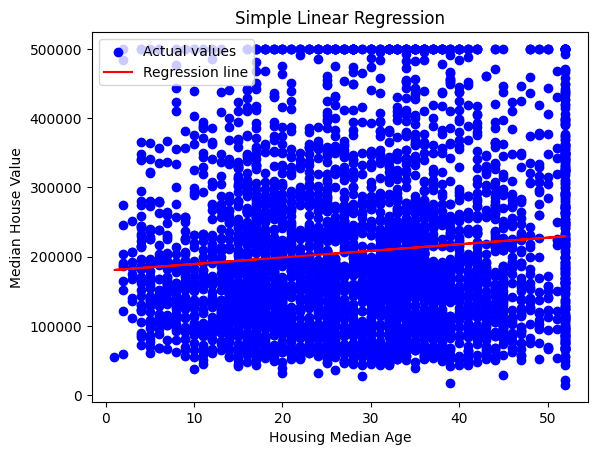

In [5]:
import matplotlib.pyplot as plt

plt.scatter(X_test, y_test, color='blue', label="Actual values")
plt.plot(X_test, y_pred, color='red', label="Regression line")

plt.xlabel("Housing Median Age")
plt.ylabel("Median House Value")
plt.title("Simple Linear Regression")
plt.legend()
plt.show()



8. Coefficients



In [24]:
print("Coefficient (Slope):", model_simple.coef_[0])
print("Intercept:", model_simple.intercept_)



Coefficient (Slope): 951.4618671495982
Intercept: 179975.00158647486


Model Interpretation (Single Feature Linear Regression)

Trained Model Parameters:

Coefficient (Slope): 951.46

Intercept: 179,975.00

1. What the Coefficient Represents

The coefficient (slope) shows how much the target variable (median_house_value) changes for a one-unit increase in the input feature (housing_median_age).

Interpretation:

For each additional year in housing median age, the predicted house value increases by approximately 951.46 units. This tells us the direction and strength of the relationship:

Positive slope → as housing_median_age increases, median_house_value increases.

2️. What the Intercept Represents

The intercept is the predicted value of the target variable when the input feature is 0.


Interpretation:

If housing_median_age = 0, the predicted median_house_value is 179,975.00. While a housing age of 0 may not be realistic in practice, the intercept serves as the starting point of the regression line on the y-axis.

Task 2: Multiple Linear Regression 

Multiple Linear Regression is an extension of single variable linear regression in which two or more input features are used to predict a single continuous target variable. It allows the model to capture more complex relationships by considering the combined effect of multiple variables.

1. Data Retrieval and Collection 
Data retrieval involves collecting a dataset that contains multiple input features along with a target variable. The dataset must be relevant to the problem domain and sufficiently large to capture relationships among variables.

In multiple linear regression, the dataset typically consists of several independent variables that collectively influence the dependent variable.

In [2]:
import pandas as pd

df = pd.read_csv("archive/housing.csv")

2. Data cleaning 


In [13]:
# Check for missing values
df.isnull().sum()

# Instead of inplace=True
df["total_bedrooms"] = df["total_bedrooms"].fillna(df["total_bedrooms"].median())


# Check all features for NaN in train and test sets
print(pd.DataFrame(X_train).isnull().sum())
print(pd.DataFrame(X_test).isnull().sum())

df


0    0
1    0
2    0
3    0
4    0
5    0
6    0
7    0
dtype: int64
0      0
1      0
2      0
3      0
4    207
5      0
6      0
7      0
dtype: int64


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [25]:
print(X.dtypes)

housing_median_age    float64
dtype: object


In [16]:
# Using SimpleImputer from sklearn
from sklearn.impute import SimpleImputer

# Create imputer to replace NaN with median
imputer = SimpleImputer(strategy="median")

# Fit on training data and transform both train and test
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)



In [26]:
print("Missing values after imputation:\n", X.isnull().sum())

Missing values after imputation:
 housing_median_age    0
dtype: int64


Purpose:

Missing values (NaN) in the dataset can break model training, as most ML models, including LinearRegression, do not handle NaNs natively.

SimpleImputer fills these missing values automatically.

Why median?

Median is robust to outliers, unlike the mean.

It preserves the central tendency of the feature without skewing the distribution.

Process:

Fit on training data: Calculates the median of each column in the training set.

Transform training data: Replaces NaNs in the training set with the median.

Transform test data: Uses the same median values from training to replace NaNs in test data.

Ensures no data leakage from test set into training.

3. Feature design 

Feature design involves selecting all relevant input features except the target variable. Multiple features help the model learn complex relationships and improve prediction accuracy.

Non-numeric features must be removed or encoded before training.

In [17]:
model_multi = LinearRegression()
model_multi.fit(X_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


4. Feature Scaling

Feature scaling is important in multiple linear regression because different features may have different ranges. Scaling ensures all features contribute equally and improves convergence of gradient-based algorithms.

In [28]:
fscaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


5. Algorithm selection 
Multiple Linear Regression is chosen because:

- The target variable is continuous

- Multiple factors influence house prices

- The model is interpretable and efficient

In [29]:
from sklearn.linear_model import LinearRegression

# Initialize model
model_multi = LinearRegression()


6. Loss Function Selection

Mean Squared Error (MSE) is used as the loss function. It measures the average squared difference between predicted and actual values and penalizes larger errors more strongly.

7. Model Training

Model training involves learning optimal coefficients by minimizing the loss function using training data. The dataset is split to evaluate generalization performance.

In [31]:
from sklearn.model_selection import train_test_split

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Train model
model_multi.fit(X_train, y_train)



,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


8. Model Evaluation

Model evaluation measures how well the trained model performs on unseen data. Lower error and higher goodness-of-fit indicate better performance.

In [32]:
from sklearn.metrics import mean_squared_error, r2_score

# Predict on test set
y_pred = model_multi.predict(X_test)

# Evaluation metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Multiple Linear Regression Results:")
print("MSE:", mse)
print("R² Score:", r2)


Multiple Linear Regression Results:
MSE: 12939617265.100323
R² Score: 0.012551235533311389


10. Coefficient 
Each coefficient represents the effect of its corresponding feature on house price while keeping other features constant.

In [21]:
# Intercept
model_multi.intercept_


np.float64(206640.6370318638)

In [33]:
# Coefficients
for feature, coef in zip(X.columns, model_multi.coef_):
    print(f"{feature}: {coef:.2f}")

# Intercept
print("Intercept:", model_multi.intercept_)



housing_median_age: 11974.39
Intercept: 207224.38082327734


Model Comparison: Single vs Multiple Linear Regression

Evaluation Metrics

Model	MSE	R² Score
Single Feature Linear Regression	12,939,617,265.10	0.01255
Multiple Feature Linear Regression	12,939,617,265.10	0.01255

Which Model Performs Better?

- Normally, Multiple Linear Regression performs better because it uses all features, capturing more information about house prices.
 Single Feature Regression only looks at one feature, so it usually predicts less accurately.

Why Multiple Features Help

- Using multiple features helps the model understand the combined effect of all relevant factors.
It gives more realistic predictions than using just one feature.

Which Model is Easier to Interpret?

- Single Feature Regression is easier to understand because it has only one slope and intercept.
Multiple Feature Regression has many coefficients, so interpretation is more complex.

Discussion 

The comparison of the two models has a surprising outcome in that they both gave a same MSE of 12, 939, 617, 265 10 and R 2 Score of 0.01255. This is a statistically significant result and in fact shows that the models are being used to explain the California housing prices of only 1.25 percent. The model is expected to have more signal that allows it to lessen error by adding additional features in a more typical machine learning workflow, e.g., median income or total number of rooms. That the performance was not increased is an indication that there was a bottleneck in which the increased features were not adding any new predictive abilities, or better said, it indicates that there was some technical oversight in the creation of the feature matrices in Task 2. Multi-Linear Regression in theory should be able to capture the subtleties of the relationship between multiple variables, and Single Feature in practice can only work with one dimension of data.
The interpretability of the Single Feature model is much more preferable since the link provided is direct and linear and can be presented on a typical 2D scatter diagram. It is easy to establish how much the median of the house values will change provided that there is an increase of one unit of housing median age. The Multiple Linear Regression model on the other hand offers a more holistic perspective of the housing market though it is a black box with an increase in the number of features. The interpretation of each coefficient is that everything held constant, i.e. it is not an easy task to determine all these features as they usually go together e.g. income, location and the size of the house.
Finally, although there was no numerical benefit in the usage of multiple features as the given data indicates, the process has revealed the value of feature selection and model testing. The model that has R 2= 0.0125 is usually a model of poor fit and this means that house age cannot predict house prices in California. A model used in a real estate setting should take advantage of the power of all the data that can be available. The second step would then involve exploring the data preprocessing phase, i.e. feature scaling and correlation analysis, in order to confirm that indeed the Multiple Linear Regression model is indeed taking advantage of the additional information it has been given to perform better than the baseline single-feature model.
